In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

### Objectives:-
1. Read Travel data as csv
2. Perform data cleaning
3. Perform feature engineering and encoding 
4. Train, test, split data
5. Train GradientBoostingClassifier and other multiple models for comparison 
6. Print and review performance metrics (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score) for both test and training data for all the models
7. Fine tune model by passing hyperparameters using RandomizedSearchCV for Random Forrest and Gradient Boosting Classifier model
8. Find best params
9. Rerun models with the best parameters
10. Print and review performance metrics (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score) for both test and training data
11. Plot AUC for Gradient Boosting Classifier

In [32]:
df = pd.read_csv('../data/raw/Travel.csv')

In [33]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


### Data Cleaning
1. Handling missing values
2. Handling duplicates
3. Check data type

In [34]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [35]:
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [36]:
df['Gender'] = df['Gender'].apply(lambda x: 'Female' if x == 'Fe Male' else x )
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [37]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [38]:
df['MaritalStatus'] = df['MaritalStatus'].apply(lambda x: 'Unmarried' if x == 'Single' else x)
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64

In [39]:
features_na = [features for features in df.columns if df[features].isnull().sum() >= 1]
for feature in features_na:
    print(feature, np.round(df[feature].isnull().mean() *100,5 ), '% missing value')

Age 4.62357 % missing value
TypeofContact 0.51146 % missing value
DurationOfPitch 5.13502 % missing value
NumberOfFollowups 0.92062 % missing value
PreferredPropertyStar 0.53191 % missing value
NumberOfTrips 2.86416 % missing value
NumberOfChildrenVisiting 1.35025 % missing value
MonthlyIncome 4.76678 % missing value


In [40]:
df[features_na].describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


In [41]:
# replace null values in categorical columns with Mode and numerical columns with Median
df.fillna({'Age': df['Age'].median()}, inplace=True)
df.fillna({'DurationOfPitch': df['DurationOfPitch'].median()}, inplace=True)
df.fillna({'NumberOfTrips': df['NumberOfTrips'].median()}, inplace=True)
df.fillna({'MonthlyIncome': df['MonthlyIncome'].median()}, inplace=True)

df.fillna({'TypeofContact': df['TypeofContact'].mode()[0]}, inplace=True)
df.fillna({'NumberOfFollowups': df['NumberOfFollowups'].mode()[0]}, inplace=True)
df.fillna({'PreferredPropertyStar': df['PreferredPropertyStar'].mode()[0]}, inplace=True)
df.fillna({'NumberOfChildrenVisiting': df['NumberOfChildrenVisiting'].mode()[0]}, inplace=True)

df.isnull().sum()



CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [42]:
# drop CustomerID as it has no influence on the dependent feature

df.drop('CustomerID', axis=1, inplace=True)

In [43]:
df.columns

Index(['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch',
       'Occupation', 'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups',
       'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus',
       'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar',
       'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='str')

### Feature Engineering

In [44]:
# combine person and children visiting column
df['TotalVisiting'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df.drop(['NumberOfChildrenVisiting', 'NumberOfPersonVisiting'], axis=1, inplace=True)

In [45]:
X,y = df.drop('ProdTaken', axis=1), df['ProdTaken']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [46]:
# Transform columns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

cat_feat = X.select_dtypes(include='str').columns
num_feat = X.select_dtypes(exclude='str').columns

num_tranformer = StandardScaler()
cat_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer([('OneHotEncoder', cat_transformer, cat_feat), ('StandardScaler', num_tranformer, num_feat)])


In [47]:
# transform only on test dataset to prevent data leakage
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

### Multiple Classifier models Implementation including Adaboost

In [48]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

models = {'Random Forest Classifier': RandomForestClassifier(),
          'Logistic Regression': LogisticRegression(),
          'Decision Tree Regressor': DecisionTreeRegressor(),
          'AdaBoostClassifier': AdaBoostClassifier(),
          'Gradient Boosting Classifier': GradientBoostingClassifier()}

for k, v in models.items():
    model = v
    model.fit(X_train, y_train)

    # make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # training model performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_roc_auc_score = roc_auc_score(y_train, y_train_pred)

    # test model performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_roc_auc_score = roc_auc_score(y_test, y_test_pred)
    
    print('==============================================')
    print(k,':- Metrics')
    print('==============================================')
    print('Train Model Performance Metrics ')
    print(f'Accuracy:- {model_train_accuracy}')
    print(f'F1:- {model_train_f1}')
    print(f'Precison:- {model_train_precision}')
    print(f'Reacll:- {model_train_recall}')
    print(f'Roc AUC Score:- {model_train_roc_auc_score}')

    print('-----------------------------------------------')

    print('Test Model Performance Metrics ')
    print(f'Accuracy:- {model_test_accuracy}')
    print(f'F1:- {model_test_f1}')
    print(f'Precison:- {model_test_precision}')
    print(f'Reacll:- {model_test_recall}')
    print(f'Roc AUC Score:- {model_test_roc_auc_score}')

    print('\n')

Random Forest Classifier :- Metrics
Train Model Performance Metrics 
Accuracy:- 1.0
F1:- 1.0
Precison:- 1.0
Reacll:- 1.0
Roc AUC Score:- 1.0
-----------------------------------------------
Test Model Performance Metrics 
Accuracy:- 0.9294478527607362
F1:- 0.9240604102218278
Precison:- 0.9692307692307692
Reacll:- 0.6596858638743456
Roc AUC Score:- 0.8273016358761817


Logistic Regression :- Metrics
Train Model Performance Metrics 
Accuracy:- 0.8460358056265984
F1:- 0.8202118738880438
Precison:- 0.7015873015873015
Reacll:- 0.30315500685871055
Roc AUC Score:- 0.6368022755136056
-----------------------------------------------
Test Model Performance Metrics 
Accuracy:- 0.83640081799591
F1:- 0.8086633047343356
Precison:- 0.691358024691358
Reacll:- 0.2931937172774869
Roc AUC Score:- 0.630713758257549


Decision Tree Regressor :- Metrics
Train Model Performance Metrics 
Accuracy:- 1.0
F1:- 1.0
Precison:- 1.0
Reacll:- 1.0
Roc AUC Score:- 1.0
-----------------------------------------------
Test 

In [49]:
# Hyperparameter tuning for Random Forest and Gradient boost. Let's find best params with RandomizedSearchCV

params_rfc = {'max_depth': [None, 5, 8, 10, 15],
          'max_features': ['auto', 5, 7, 8],
          'min_samples_split': [2, 8, 15, 20],
          'n_estimators': [100, 200, 500, 1000]}
params_gradient = {'loss':['log_loss', 'exponential'],
                   'criterion': ['friedman_mse', 'squared_error'],
                   'min_samples_split': [2, 8, 15, 20],
                   'n_estimators': [100, 200, 500],
                   'max_depth': [None, 5, 8, 10, 15]
                   }

In [50]:
from sklearn.model_selection import RandomizedSearchCV

random_cv_models = [('RF', RandomForestClassifier(), params_rfc), ('GradientBoostingClassifier', GradientBoostingClassifier(), params_gradient)]
model_best_param = {}
for name, model, param in random_cv_models:
    random = RandomizedSearchCV(estimator=model, param_distributions=param, n_iter=100, cv=3, verbose=2, n_jobs= -1 )
    random.fit(X_train, y_train)
    model_best_param[name] = random.best_params_

for name in model_best_param:
    print('==========================')
    print(f'--------- Model {name} best params -----------')
    print(model_best_param[name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END max_depth=None, max_features=7, min_samples_split=15, n_estimators=200; total time=   1.3s
[CV] END max_depth=None, max_features=7, min_samples_split=15, n_estimators=200; total time=   1.3s
[CV] END max_depth=None, max_features=7, min_samples_split=15, n_estimators=200; total time=   1.3s
[CV] END max_depth=15, max_features=7, min_samples_split=15, n_estimators=200; total time=   1.2s
[CV] END max_depth=15, max_features=7, min_samples_split=15, n_estimators=200; total time=   1.3s
[CV] END max_depth=None, max_features=auto, min_samples_split=20, n_estimators=1000; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_split=20, n_estimators=1000; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_split=15, n_estimators=500; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_split=15, n_estimators=500; total time=   0.0s
[CV] END max_depth=None, ma

In [51]:
# let's rexecute previously created Random Forrest and GradientBoosting Models with best params and review the prformance metrics


models = {'Random Forest Classifier': RandomForestClassifier(n_estimators=model_best_param['RF']['n_estimators'],
                                                              min_samples_split=model_best_param['RF']['min_samples_split'], 
                                                              max_features=model_best_param['RF']['max_features'], 
                                                              max_depth=model_best_param['RF']['max_depth'], n_jobs=-1),
          'Gradient Boost Classifier': GradientBoostingClassifier(n_estimators=model_best_param['GradientBoostingClassifier']['n_estimators'],
                                                                  loss=model_best_param['GradientBoostingClassifier']['loss'],
                                                                  max_depth=model_best_param['GradientBoostingClassifier']['max_depth'],
                                                                  criterion=model_best_param['GradientBoostingClassifier']['criterion'],
                                                                  min_samples_split=model_best_param['GradientBoostingClassifier']['min_samples_split']
                                                                  )}
roc_auc = {}
for k, v in models.items():
    model = v
    model.fit(X_train, y_train)

    # make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # training model performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_roc_auc_score = roc_auc_score(y_train, y_train_pred)

    # test model performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_roc_auc_score = roc_auc_score(y_test, y_test_pred)

    roc_auc[k] = model_test_roc_auc_score

    print('======================================')
    print(k,':- Metrics')
    print('======================================')
    print('Train Model Performance Metrics ')
    print(f'Accuracy:- {model_train_accuracy}')
    print(f'F1:- {model_train_f1}')
    print(f'Precison:- {model_train_precision}')
    print(f'Reacll:- {model_train_recall}')
    print(f'Roc AUC Score:- {model_train_roc_auc_score}')

    print('---------------------------------------')

    print('Test Model Performance Metrics ')
    print(f'Accuracy:- {model_test_accuracy}')
    print(f'F1:- {model_test_f1}')
    print(f'Precison:- {model_test_precision}')
    print(f'Reacll:- {model_test_recall}')
    print(f'Roc AUC Score:- {model_test_roc_auc_score}')

    print('\n')

Random Forest Classifier :- Metrics
Train Model Performance Metrics 
Accuracy:- 0.9989769820971867
F1:- 0.9989758963204138
Precison:- 1.0
Reacll:- 0.9945130315500685
Roc AUC Score:- 0.9972565157750343
---------------------------------------
Test Model Performance Metrics 
Accuracy:- 0.934560327198364
F1:- 0.9302588265628817
Precison:- 0.9635036496350365
Reacll:- 0.6910994764397905
Roc AUC Score:- 0.8423731181436565


Gradient Boost Classifier :- Metrics
Train Model Performance Metrics 
Accuracy:- 1.0
F1:- 1.0
Precison:- 1.0
Reacll:- 1.0
Roc AUC Score:- 1.0
---------------------------------------
Test Model Performance Metrics 
Accuracy:- 0.9621676891615542
F1:- 0.9610480063917827
Precison:- 0.9695121951219512
Reacll:- 0.8324607329842932
Roc AUC Score:- 0.9130537464159078




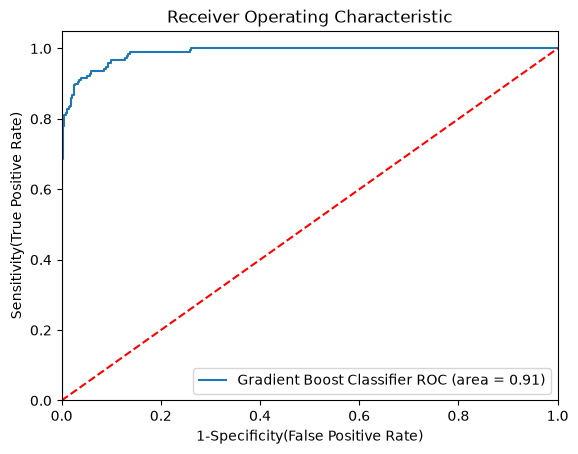

In [52]:
# let's plot Gradient Boost AUC

plt.figure()

auc_models = [{'label': 'Gradient Boost Classifier', 'model': GradientBoostingClassifier(n_estimators=model_best_param['GradientBoostingClassifier']['n_estimators'],
                                                                  loss=model_best_param['GradientBoostingClassifier']['loss'],
                                                                  max_depth=model_best_param['GradientBoostingClassifier']['max_depth'],
                                                                  criterion=model_best_param['GradientBoostingClassifier']['criterion'],
                                                                  min_samples_split=model_best_param['GradientBoostingClassifier']['min_samples_split']),
                                                                    'auc_score': round(roc_auc['Gradient Boost Classifier'], 4)}]

for algo in auc_models:
    model = algo['model']
    model.fit(X_train, y_train)

    fpr, tpr, threshold = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc_score']))

# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show() 

